In [2]:
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
def load_video(video_path):
    """Load video and return video capture object and properties"""
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        raise ValueError(f"Error opening video file: {video_path}")
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Video: {video_path}")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps}")
    print(f"  Total Frames: {frame_count}")
    print()
    
    return cap, fps, frame_count, width, height

def calculate_ssim_scores(video1_path, video2_path):
    """Calculate SSIM scores between two videos frame by frame"""
    
    # Load both videos
    print("Loading videos...")
    cap1, fps1, frames1, w1, h1 = load_video(video1_path)
    cap2, fps2, frames2, w2, h2 = load_video(video2_path)
    
    # Check if videos have compatible properties
    if frames1 != frames2:
        print(f"Warning: Videos have different frame counts ({frames1} vs {frames2})")
        print(f"Will process {min(frames1, frames2)} frames")
    
    if (w1, h1) != (w2, h2):
        print(f"Warning: Videos have different resolutions ({w1}x{h1} vs {w2}x{h2})")
        print("Frames will be resized to match the first video")
    
    # Calculate SSIM for each frame
    ssim_scores = []
    frame_numbers = []
    min_frames = min(frames1, frames2)
    
    print(f"\nCalculating SSIM scores for {min_frames} frames...")
    
    for i in tqdm(range(min_frames)):
        ret1, frame1 = cap1.read()
        ret2, frame2 = cap2.read()
        
        if not ret1 or not ret2:
            break
        
        # Resize frame2 if dimensions don't match
        if (w1, h1) != (w2, h2):
            frame2 = cv2.resize(frame2, (w1, h1))
        
        # Convert to grayscale for SSIM calculation
        gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
        
        # Calculate SSIM
        score = ssim(gray1, gray2, data_range=gray1.max() - gray1.min())
        ssim_scores.append(score)
        frame_numbers.append(i)
    
    # Release video captures
    cap1.release()
    cap2.release()
    
    return np.array(ssim_scores), np.array(frame_numbers)

def plot_ssim_results(ssim_scores, frame_numbers):
    """Plot SSIM scores over frames"""
    
    # Calculate statistics
    mean_ssim = np.mean(ssim_scores)
    std_ssim = np.std(ssim_scores)
    min_ssim = np.min(ssim_scores)
    max_ssim = np.max(ssim_scores)
    
    print(f"\n{'='*50}")
    print(f"SSIM Statistics:")
    print(f"{'='*50}")
    print(f"Mean SSIM:   {mean_ssim:.4f}")
    print(f"Std Dev:     {std_ssim:.4f}")
    print(f"Min SSIM:    {min_ssim:.4f} (Frame {frame_numbers[np.argmin(ssim_scores)]})")
    print(f"Max SSIM:    {max_ssim:.4f} (Frame {frame_numbers[np.argmax(ssim_scores)]})")
    print(f"{'='*50}\n")
    
    # Create plot
    plt.figure(figsize=(12, 6))
    plt.plot(frame_numbers, ssim_scores, linewidth=1, alpha=0.7)
    plt.axhline(y=mean_ssim, color='r', linestyle='--', label=f'Mean SSIM: {mean_ssim:.4f}')
    plt.xlabel('Frame Number')
    plt.ylabel('SSIM Score')
    plt.title('Structural Similarity Index (SSIM) Between Videos')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim([0, 1])
    plt.tight_layout()
    plt.show()
    
    return mean_ssim, std_ssim, min_ssim, max_ssim

Loading videos...
Video: /home/poorna/Downloads/dataa/1st_10min/clip_004.mp4
  Resolution: 1920x1080
  FPS: 23.98
  Total Frames: 47

Video: ./output_videos_gemini/idx_4.mp4
  Resolution: 1280x720
  FPS: 24.0
  Total Frames: 192

Will process 47 frames
Frames will be resized to match the first video

Calculating SSIM scores for 47 frames...


100%|██████████| 47/47 [00:08<00:00,  5.77it/s]



SSIM Statistics:
Mean SSIM:   0.2553
Std Dev:     0.0096
Min SSIM:    0.2413 (Frame 44)
Max SSIM:    0.2852 (Frame 0)



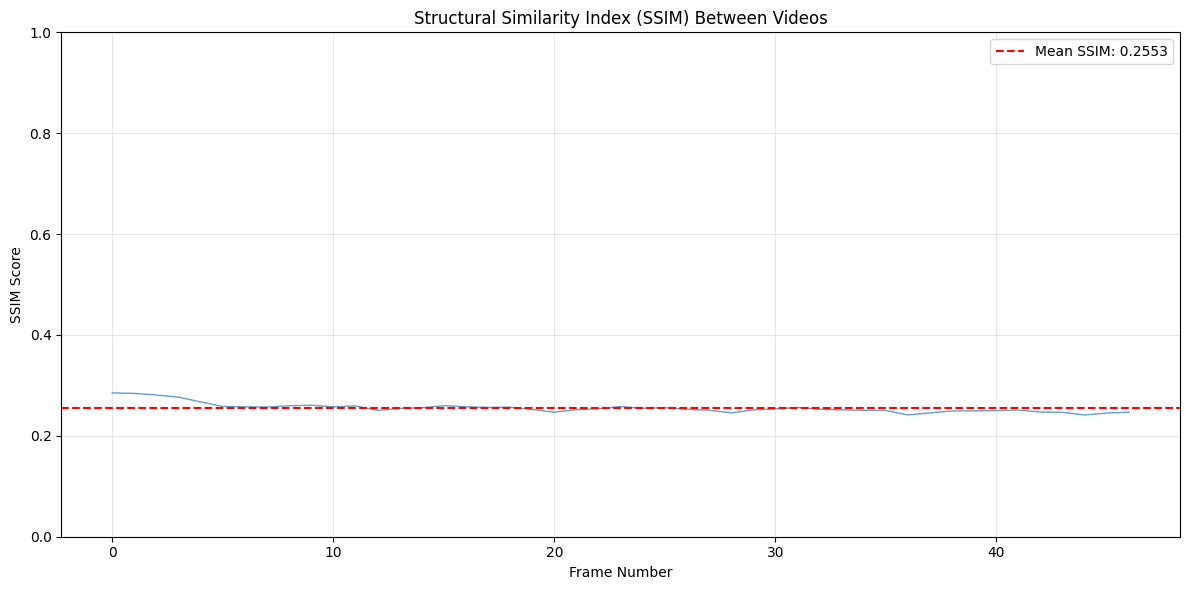

In [13]:
# Example usage
if __name__ == "__main__":
    # Replace these with your actual video file paths
    video1_path = "/home/poorna/Downloads/dataa/1st_10min/clip_004.mp4"  # Original video
    video2_path = "./output_videos_gemini/idx_4.mp4"  # Reconstructed/compared video
    
    try:
        # Calculate SSIM scores
        ssim_scores, frame_numbers = calculate_ssim_scores(video1_path, video2_path)
        
        # Plot and display results
        plot_ssim_results(ssim_scores, frame_numbers)
        
    except Exception as e:
        print(f"Error: {e}")